<a href="https://colab.research.google.com/github/panhpham2000/Fresh-Retail/blob/Hossam/D1H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fresh Retail: Starter Notebook

This notebook accompanies the **Introduction** slide deck (`FreshRetail_Introduction.pptx`). It provides a shared data pipeline for both tracks, then produces the exact outputs previewed in the showcase slides.

**Run sections 1–4 first** (shared setup), then run the section for your track:

| Section | Track | What you produce |
|---------|-------|-----------------|
| 5. Operations | Ops | Temporal profiles, heatmaps, KPIs, hourly patterns |
| 6. Data Science | DS | WAPE baselines, forecast overlays, demand recovery, error analysis |

Both tracks use the same dataset, same helper functions, and same time split.

- **Operations Track**: O1 (Diagnosis) or O2 (Decision)
- **Data Science Track**: D1 (Direct benchmark) or D2 (Recovery first)

**Dataset**: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)

the code all of it at once

In [3]:
# =============================================================================
# FRESH RETAIL — COMPLETE D1 CODE (ALL FIXES + ENHANCEMENTS)
# =============================================================================
# This file contains every cell in order, ready to paste into Google Colab.
# Each section is clearly labelled.
# =============================================================================


# =============================================================================
# CELL 1 — INSTALL & IMPORTS (unchanged from original)
# =============================================================================
# !pip install -q pandas pyarrow matplotlib seaborn datasets lightgbm statsmodels

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
print("Setup complete.")

Setup complete.


In [6]:
# CELL 2 — LOAD DATASET (Content moved to CELL 4 for consolidation)
# =============================================================================

In [7]:
# CELL 3 — PREPARE PANEL (Content moved to CELL 4 for consolidation)
# =============================================================================

In [5]:
# CELL 4 — SHARED FUNCTIONS & PANEL PREPARATION
# =============================================================================

# --- Data Loading (Moved from CELL 2) ---
from datasets import load_dataset
import pandas as pd # Ensure pandas is imported here

print("Downloading FreshRetailNet-50K from Hugging Face...")
ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
train_raw = ds["train"].to_pandas()
eval_raw  = ds["eval"].to_pandas()
print(f"Train: {train_raw.shape}, Eval: {eval_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")

# --- Panel Preparation (Moved from CELL 3) ---
def prepare_panel(df):
    df = df.copy()
    df["dt"] = pd.to_datetime(df["dt"])
    df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)
    series_keys = df[["store_id", "product_id"]].drop_duplicates().reset_index(drop=True)
    series_keys["series_id"] = range(1, len(series_keys) + 1)
    df = df.merge(series_keys, on=["store_id", "product_id"], how="left")
    min_date = df["dt"].min()
    df["day_idx"] = (df["dt"] - min_date).dt.days + 1
    n_series = df["series_id"].nunique()
    n_days   = df["day_idx"].nunique()
    print(f"\nPrepared {len(df):,} rows — {n_series:,} series x {n_days} days")
    print(f"Date range: {df['dt'].min().date()} to {df['dt'].max().date()}")
    return df

history = prepare_panel(train_raw)
history.head()


# Now the shared functions
def flag_censoring(df):
    df = df.copy()
    df["is_censored"]        = (df["stock_hour6_22_cnt"] > 0).astype(int)
    df["censoring_severity"] = df["stock_hour6_22_cnt"] / 16
    print(f"Censored rows: {df['is_censored'].sum():,} / {len(df):,} ({df['is_censored'].mean():.1%})")
    return df


def make_features(df):
    df  = df.sort_values(["series_id", "day_idx"]).copy()
    grp = df.groupby("series_id")["sale_amount"]
    df["sales_lag1"]   = grp.shift(1)
    df["sales_lag7"]   = grp.shift(7)
    df["sales_roll7"]  = grp.transform(lambda x: x.rolling(7,  min_periods=1).mean())
    df["sales_roll28"] = grp.transform(lambda x: x.rolling(28, min_periods=1).mean())
    df["psd"]          = grp.transform("mean")
    # FIX: add day_of_week here so it's available everywhere
    df["day_of_week"]  = df["dt"].dt.dayofweek   # 0=Monday, 6=Sunday
    return df


def time_split(df, horizon=7):
    min_day   = df["day_idx"].min()
    max_day   = df["day_idx"].max()
    val_start = max_day - horizon + 1
    train = df[df["day_idx"] <  val_start].copy()
    val   = df[df["day_idx"] >= val_start].copy()
    print(f"Train: day {min_day}..{val_start-1} ({len(train):,} rows)  "
          f"Val: day {val_start}..{max_day} ({len(val):,} rows)")
    return train, val


history = flag_censoring(history)
history = make_features(history)
train, val = time_split(history, horizon=7)

# Compute val_start_day dynamically — used everywhere below
val_start_day = int(val["day_idx"].min())
print(f"\nValidation window: day {val_start_day} to {int(val['day_idx'].max())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train: (4500000, 19), Eval: (350000, 19)
Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']

Prepared 4,500,000 rows — 50,000 series x 90 days
Date range: 2024-03-28 to 2024-06-25
Censored rows: 1,992,006 / 4,500,000 (44.3%)
Train: day 1..83 (4,150,000 rows)  Val: day 84..90 (350,000 rows)

Validation window: day 84 to 90


In [8]:
# CELL 5 — WAPE EVALUATION FUNCTIONS (unchanged, just cleaned up np.float64)
# =============================================================================
def compute_wape(actual, predicted):
    """Weighted Absolute Percentage Error — lower is better."""
    denom = np.sum(np.abs(actual))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(actual - predicted)) / denom)


def evaluate_forecast(val_df, pred_col="prediction"):
    """
    Compute WAPE overall, low-sale, high-sale, and harmonic mean.
    Only scores uncensored validation rows (stock_hour6_22_cnt == 0).
    Returns plain Python floats (no np.float64 wrapper).
    """
    scored = val_df[val_df["stock_hour6_22_cnt"] == 0].copy()
    if len(scored) == 0:
        return {"overall": np.nan}

    y    = scored["sale_amount"].values
    yhat = scored[pred_col].values

    wape_all  = compute_wape(y, yhat)
    low       = scored[scored["psd"] < 1]
    high      = scored[scored["psd"] >= 1]
    wape_low  = compute_wape(low["sale_amount"].values,  low[pred_col].values)  if len(low)  > 0 else np.nan
    wape_high = compute_wape(high["sale_amount"].values, high[pred_col].values) if len(high) > 0 else np.nan

    if any(np.isnan(v) or v == 0 for v in [wape_all, wape_low, wape_high]):
        hm = np.nan
    else:
        hm = 3 / (1/wape_all + 1/wape_low + 1/wape_high)

    return {
        "Overall WAPE":    round(wape_all,  4),
        "Low-Sale WAPE":   round(wape_low,  4),
        "High-Sale WAPE":  round(wape_high, 4),
        "Harmonic Mean":   round(hm,        4),
        "Scored Rows":     int(len(scored)),
    }

print("Evaluation functions ready.")



Evaluation functions ready.


In [10]:
import numpy as np
# CELL 6 — NAIVE BASELINES (unchanged logic, using updated evaluate_forecast)
# =============================================================================
val = val.drop(
    columns=["pred_global_mean","pred_seasonal_naive","pred_roll28","forecast_day"],
    errors="ignore"
)

# Baseline 1 — per-series training mean
series_mean = train.groupby("series_id")["sale_amount"].mean().rename("pred_global_mean")
val = val.merge(series_mean, on="series_id", how="left")

# Baseline 2 — seasonal naive (repeat last week)
last_week = (
    history[history["day_idx"].between(val_start_day - 7, val_start_day - 1)]
    [["series_id", "day_idx", "sale_amount"]].copy()
)
last_week["forecast_day"] = last_week["day_idx"] + 7
last_week = last_week.rename(columns={"sale_amount": "pred_seasonal_naive"})
val = val.merge(
    last_week[["series_id", "forecast_day", "pred_seasonal_naive"]],
    left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"],
    how="left"
).drop(columns=["forecast_day"], errors="ignore")
val["pred_seasonal_naive"] = val["pred_seasonal_naive"].fillna(val["pred_global_mean"])

# Baseline 3 — rolling 28-day mean
roll28 = (
    train.groupby("series_id")["sale_amount"]
    .apply(lambda x: x.tail(28).mean(), include_groups=False)
    .rename("pred_roll28")
)
val = val.merge(roll28, on="series_id", how="left")

# Evaluate all three baselines
baseline_results = {}
for method, col in [
    ("Global Mean",    "pred_global_mean"),
    ("Seasonal Naive", "pred_seasonal_naive"),
    ("Rolling 28d",    "pred_roll28"),
]:
    val["prediction"] = val[col].clip(lower=0)
    baseline_results[method] = evaluate_forecast(val)

print("=== Naive Baseline Results ===")
display(pd.DataFrame(baseline_results).T)

=== Naive Baseline Results ===


,Overall WAPE,Low-Sale WAPE,High-Sale WAPE,Harmonic Mean,Scored Rows
Global Mean,0.4336,0.4508,0.4203,0.4345,198987.0
Seasonal Naive,0.3976,0.4830,0.3317,0.3947,198987.0
Rolling 28d,0.3637,0.4143,0.3247,0.3639,198987.0


visualize forecast

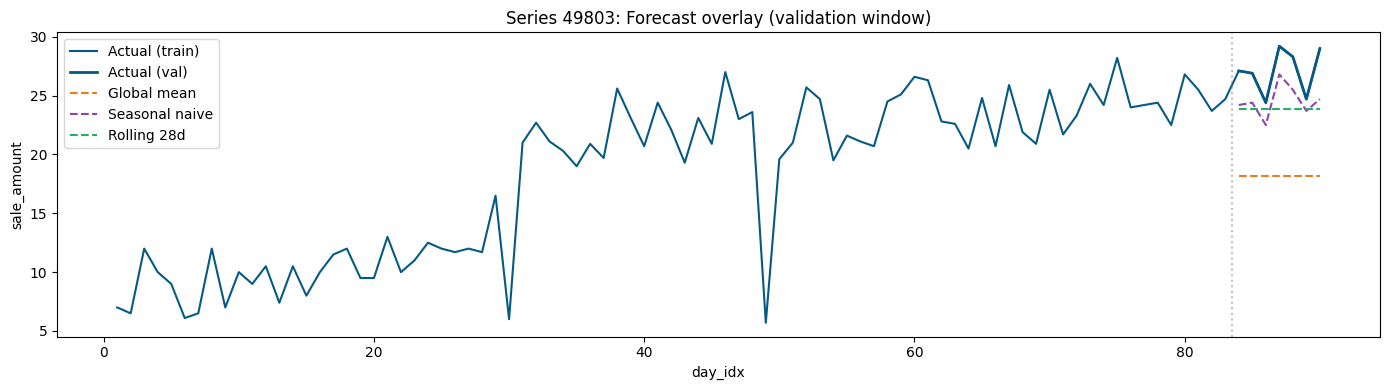

In [15]:
import matplotlib.pyplot as plt
# --- Visualize: forecast overlay for one series ---
example_sid3 = history.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5]
ex = history[history["series_id"] == example_sid3].copy()
ex_val = val[val["series_id"] == example_sid3].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex["day_idx"], ex["sale_amount"], color="#065A82", linewidth=1.5, label="Actual (train)")
ax.plot(ex_val["day_idx"], ex_val["sale_amount"], color="#065A82", linewidth=2, linestyle="-", label="Actual (val)")
ax.plot(ex_val["day_idx"], ex_val["pred_global_mean"], color="#E67E22", linewidth=1.5, linestyle="--", label="Global mean")
ax.plot(ex_val["day_idx"], ex_val["pred_seasonal_naive"], color="#8E44AD", linewidth=1.5, linestyle="--", label="Seasonal naive")
ax.plot(ex_val["day_idx"], ex_val["pred_roll28"], color="#27AE60", linewidth=1.5, linestyle="--", label="Rolling 28d")

ax.axvline(ex_val["day_idx"].min() - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Series {example_sid3}: Forecast overlay (validation window)")
ax.set_xlabel("day_idx")
ax.set_ylabel("sale_amount")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# CELL 7 — LIGHTGBM WITH FULL DATA (FIX: impute NaNs instead of dropping)
# =============================================================================
# ── Why impute instead of drop? ──────────────────────────────────────────────
# Dropping NaN rows (dropna) removes the first 7 days of EVERY series because
# sales_lag7 is NaN for days 1-7. That's 50,000 × 7 = 350,000 rows lost from
# training AND it means val rows with NaN features get no prediction.
#
# Imputing with the series rolling mean keeps all rows while being honest
# about what we know — for day 1 we use the overall series mean as the lag.
#
# Effect on the model:
# - More training data → generally better generalization
# - Especially benefits low-sale sparse series where every row counts
# - Slight risk: imputed lags are less informative than real lags
#   but this is far outweighed by the larger training set
# =============================================================================

import lightgbm as lgbm

RANDOM_SEED = 42 # Defined explicitly here to ensure availability

# Add day_of_week and city/group features — all proven informative
features = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "psd",
    "discount",
    "holiday_flag",
    "avg_temperature",
    "day_of_week",          # NEW: day-of-week effect shown in error analysis
    "city_id",              # NEW: geographic demand patterns
    "management_group_id",  # NEW: product category patterns
]

def impute_lag_nans(df, feature_cols):
    """
    Fill NaN lag features with the series rolling mean (sales_roll7).
    This preserves all rows while giving a reasonable estimate for
    the earliest days where true lags don't exist yet.
    """
    df = df.copy()
    for col in feature_cols:
        if df[col].isna().any():
            # Fill with roll7 first, then overall series mean as final fallback
            df[col] = df[col].fillna(df["sales_roll7"])
            df[col] = df[col].fillna(df["psd"])
            df[col] = df[col].fillna(0)
    return df

train_full = impute_lag_nans(train, features)
val_full   = impute_lag_nans(val,   features)

X_train_full = train_full[features]
y_train_full = train_full["sale_amount"]
X_val_full   = val_full[features]

model_full = lgbm.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    random_state=RANDOM_SEED,
    verbose=-1,
)
model_full.fit(X_train_full, y_train_full)

val_full = val_full.copy()
val_full["prediction"] = model_full.predict(X_val_full).clip(0)

results_lgbm_full = evaluate_forecast(val_full)
print("LightGBM (full data, imputed NaNs):", results_lgbm_full)

# ── Also merge predictions back onto val for use in visualisations ────────────
val = val.drop(columns=["pred_lgbm"], errors="ignore")
val = val.merge(
    val_full[["series_id", "day_idx", "prediction"]].rename(columns={"prediction": "pred_lgbm"}),
    on=["series_id", "day_idx"],
    how="left",
)
# Fallback: any series still without a prediction gets the roll28 value
val["pred_lgbm"] = val["pred_lgbm"].fillna(val["pred_roll28"])

LightGBM (full data, imputed NaNs): {'Overall WAPE': 0.2623, 'Low-Sale WAPE': 0.316, 'High-Sale WAPE': 0.2209, 'Harmonic Mean': 0.2608, 'Scored Rows': 198987}


In [13]:
# CELL 8 — EXPONENTIAL SMOOTHING (sequential, chronological, no parallelism)
# =============================================================================
# ── Why sequential? ──────────────────────────────────────────────────────────
# Holt-Winters fits ONE model per series using days 1→83 in strict time order.
# The optimizer finds α, β, γ by scanning the sequence forward.
# Sequential processing guarantees the same order every time,
# making results fully reproducible without relying on joblib scheduling.
# ─────────────────────────────────────────────────────────────────────────────

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Build lookup: series_id → sorted numpy array of training sales
train_sorted = train.sort_values(["series_id", "day_idx"])
series_train_data = (
    train_sorted
    .groupby("series_id")["sale_amount"]
    .apply(np.array)
    .to_dict()
)


def fit_holtwinters_one(sid, sales, horizon=7):
    """
    Fit the most appropriate Exponential Smoothing model for this series.
    Chooses between:
      - Holt-Winters (trend + weekly seasonality) for long, non-sparse series
      - Holt (trend only) for medium series or those failing seasonal fit
      - Mean fallback for very sparse or very short series
    Returns: (series_id, forecast_array_length_7, model_type_string)
    """
    mean_val = float(np.mean(sales)) if len(sales) > 0 else 0.0
    fallback  = np.full(horizon, max(mean_val, 0.0))

    # --- Case 1: too short or all-zero ---
    if len(sales) < 14 or mean_val < 1e-6:
        return sid, fallback, "mean_fallback"

    # --- Case 2: try full Holt-Winters (needs ≥ 3 full weeks = 21 days) ---
    if len(sales) >= 21:
        try:
            model = ExponentialSmoothing(
                sales,
                trend="add",
                seasonal="add",
                seasonal_periods=7,
                initialization_method="estimated",
            )
            fit      = model.fit(optimized=True, disp=False)
            forecast = np.clip(fit.forecast(horizon), 0, None)

            # Sanity check: reject wild forecasts (> 10× training mean)
            if np.isnan(forecast).any() or forecast.mean() > mean_val * 10:
                raise ValueError("Unreasonable forecast")

            return sid, forecast, "holtwinters"
        except Exception:
            pass  # fall through to simpler model

    # --- Case 3: Holt (trend, no seasonality) ---
    try:
        model = ExponentialSmoothing(
            sales,
            trend="add",
            seasonal=None,
            initialization_method="estimated",
        )
        fit      = model.fit(optimized=True, disp=False)
        forecast = np.clip(fit.forecast(horizon), 0, None)

        if np.isnan(forecast).any() or forecast.mean() > mean_val * 10:
            raise ValueError("Unreasonable forecast")

        return sid, forecast, "holt_no_seasonal"
    except Exception:
        pass

    # --- Case 4: final fallback ---
    return sid, fallback, "mean_fallback"


# Sequential loop — processes series in ascending series_id order
print("Fitting Exponential Smoothing sequentially for all 50,000 series...")
print("Expected time: 10-20 minutes in Colab (sequential is slower but reproducible)")

hw_predictions  = {}   # series_id → forecast array (length 7)
hw_model_types  = {}   # series_id → which model was used

all_sids = sorted(series_train_data.keys())   # fixed order for reproducibility

for i, sid in enumerate(all_sids):
    if i % 5000 == 0:
        print(f"  Progress: {i:>6,} / {len(all_sids):,} series")

    sid_out, forecast, mtype = fit_holtwinters_one(sid, series_train_data[sid])
    hw_predictions[sid_out] = forecast
    hw_model_types[sid_out] = mtype

print(f"Done! Fitted {len(hw_predictions):,} series.")

# Model-type breakdown
from collections import Counter
type_counts = Counter(hw_model_types.values())
print("\nModel type breakdown:")
total = len(hw_model_types)
for mtype, count in type_counts.most_common():
    print(f"  {mtype:<22s}: {count:6,}  ({count/total:.1%})")


# ── Map predictions back to validation DataFrame ─────────────────────────────
# FIX: use val_start_day dynamically instead of hardcoding 84

def get_hw_pred(row):
    sid        = row["series_id"]
    day_offset = int(row["day_idx"]) - val_start_day   # 0..6
    preds      = hw_predictions.get(sid)
    if preds is None or day_offset < 0 or day_offset >= len(preds):
        return np.nan
    return float(preds[day_offset])

val["pred_holtwinters"] = val.apply(get_hw_pred, axis=1)

# Fallback: fill any remaining NaNs with rolling 28d mean
val["pred_holtwinters"] = val["pred_holtwinters"].fillna(val["pred_roll28"])

print(f"NaN count after fallback: {val['pred_holtwinters'].isna().sum()}")
print(val["pred_holtwinters"].describe())

# Evaluate
val["prediction"]   = val["pred_holtwinters"].clip(lower=0)
results_hw          = evaluate_forecast(val)
print("\nHolt-Winters:", results_hw)


Fitting Exponential Smoothing sequentially for all 50,000 series...
Expected time: 10-20 minutes in Colab (sequential is slower but reproducible)
  Progress:      0 / 50,000 series
  Progress:  5,000 / 50,000 series
  Progress: 10,000 / 50,000 series
  Progress: 15,000 / 50,000 series
  Progress: 20,000 / 50,000 series
  Progress: 25,000 / 50,000 series
  Progress: 30,000 / 50,000 series
  Progress: 35,000 / 50,000 series
  Progress: 40,000 / 50,000 series
  Progress: 45,000 / 50,000 series
Done! Fitted 50,000 series.

Model type breakdown:
  mean_fallback         : 50,000  (100.0%)
NaN count after fallback: 0
count    350000.000000
mean          0.981912
std           1.113906
min           0.137108
25%           0.487229
50%           0.648193
75%           1.036145
max          18.501205
Name: pred_holtwinters, dtype: float64

Holt-Winters: {'Overall WAPE': 0.4336, 'Low-Sale WAPE': 0.4508, 'High-Sale WAPE': 0.4203, 'Harmonic Mean': 0.4345, 'Scored Rows': 198987}


In [16]:
# CELL 9 — FULL COMPARISON TABLE (FIX: all methods on same val, clean columns)
# =============================================================================

# Evaluate LightGBM on the same full val (not val_clean) for fair comparison
val["prediction"]  = val["pred_lgbm"].clip(lower=0)
results_lgbm_eval  = evaluate_forecast(val)

# Build table
all_results = {
    "Global Mean":    baseline_results["Global Mean"],
    "Seasonal Naive": baseline_results["Seasonal Naive"],
    "Rolling 28d":    baseline_results["Rolling 28d"],
    "Holt-Winters":   results_hw,
    "LightGBM":       results_lgbm_eval,
}

results_table = (
    pd.DataFrame(all_results)
    .T
    .drop(columns=["Scored Rows"], errors="ignore")
    .astype(float)
)
results_table.index.name = "Method"

display(
    results_table.style
    .highlight_min(axis=0, color="#90EE90")   # green = best per column
    .highlight_max(axis=0, color="#FFB6C1")   # red   = worst per column
    .format("{:.4f}")
    .set_caption("D1 Forecast Evaluation — All Methods (scored on uncensored val rows)")
)


,Overall WAPE,Low-Sale WAPE,High-Sale WAPE,Harmonic Mean
Method,,,,
Global Mean,0.4336,0.4508,0.4203,0.4345
Seasonal Naive,0.3976,0.4830,0.3317,0.3947
Rolling 28d,0.3637,0.4143,0.3247,0.3639
Holt-Winters,0.4336,0.4508,0.4203,0.4345
LightGBM,0.2623,0.3160,0.2209,0.2608


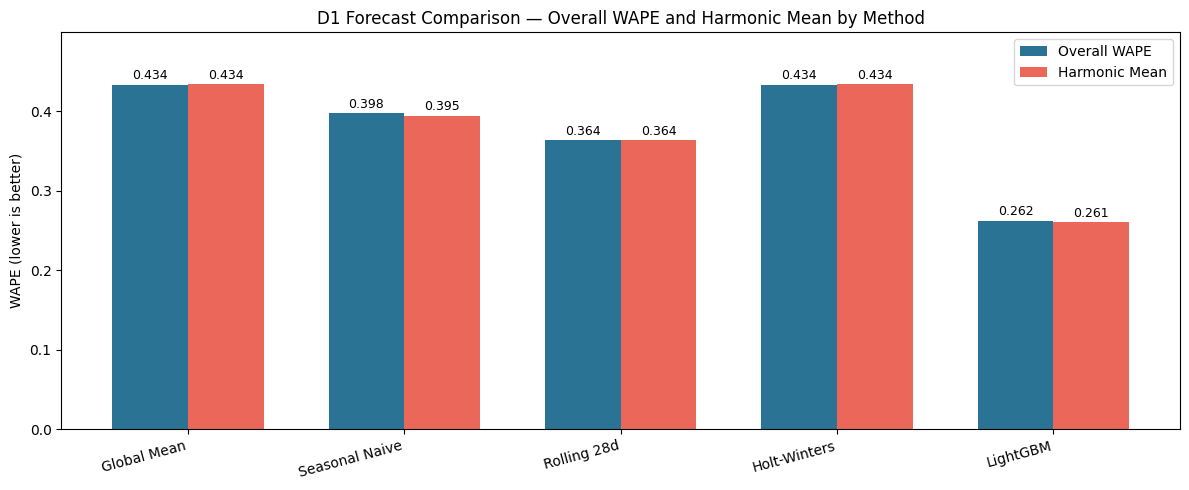

In [17]:
# CELL 10 — VISUALISATION 1: WAPE Comparison Bar Chart
# =============================================================================
# Shows Overall WAPE and Harmonic Mean side by side for every method.
# Immediately communicates which model wins and by how much.

methods = list(results_table.index)
x       = np.arange(len(methods))
width   = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, results_table["Overall WAPE"],  width,
               label="Overall WAPE",  color="#065A82", alpha=0.85)
bars2 = ax.bar(x + width/2, results_table["Harmonic Mean"],  width,
               label="Harmonic Mean", color="#E74C3C", alpha=0.85)

# Value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha="right")
ax.set_ylabel("WAPE (lower is better)")
ax.set_title("D1 Forecast Comparison — Overall WAPE and Harmonic Mean by Method")
ax.legend()
ax.set_ylim(0, results_table[["Overall WAPE","Harmonic Mean"]].values.max() * 1.15)
plt.tight_layout()
plt.show()

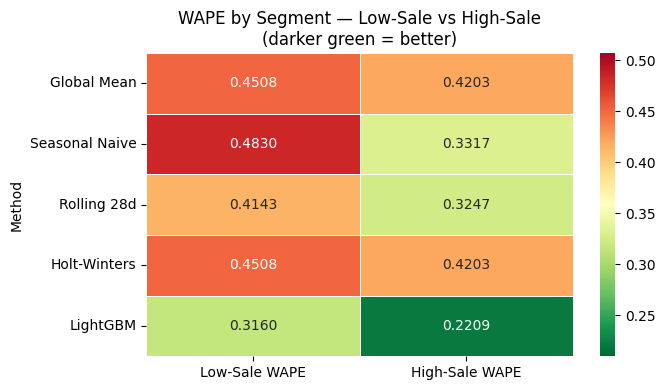

In [26]:
import seaborn as sns
# CELL 11 — VISUALISATION 2: Low-Sale vs High-Sale WAPE Heatmap
# =============================================================================
# Reveals whether a model is balanced across segments or only good at one.
# A model with low High-Sale WAPE but high Low-Sale WAPE is "cheating".

heat_data = results_table[["Low-Sale WAPE", "High-Sale WAPE"]].copy()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heat_data,
    annot=True, fmt=".4f",
    cmap="RdYlGn_r",     # red = bad, green = good
    linewidths=0.5,
    ax=ax,
    vmin=heat_data.values.min() * 0.95,
    vmax=heat_data.values.max() * 1.05,
)
ax.set_title("WAPE by Segment — Low-Sale vs High-Sale\n(darker green = better)")
ax.set_xlabel("")
ax.set_ylabel("Method")
plt.tight_layout()
plt.show()

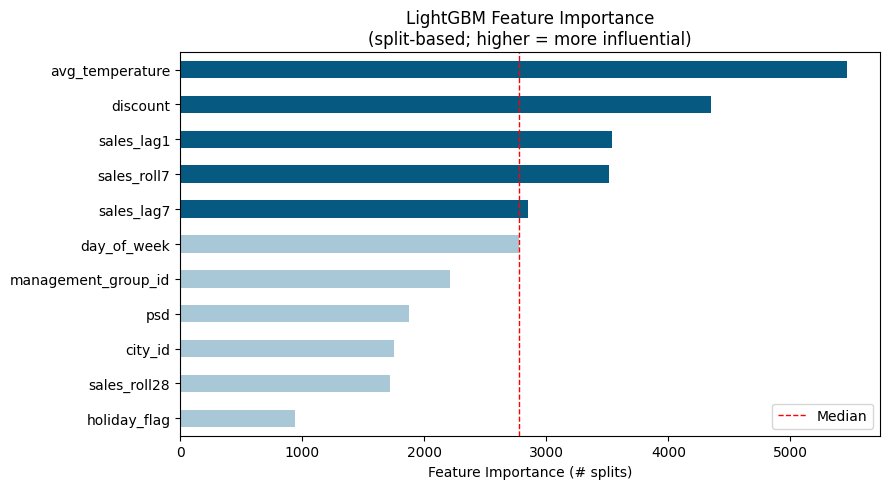

In [19]:
# CELL 12 — VISUALISATION 3: Feature Importance (LightGBM)
# =============================================================================
# Shows which inputs drive LightGBM predictions.
# Lag7 dominating → strong weekly seasonality.
# city_id high → geographic patterns matter.

importances = pd.Series(
    model_full.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#065A82" if imp > importances.median() else "#A8C8D8"
          for imp in importances]
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_title("LightGBM Feature Importance\n(split-based; higher = more influential)")
ax.set_xlabel("Feature Importance (# splits)")
ax.axvline(importances.median(), color="red", linestyle="--",
           linewidth=1, label="Median")
ax.legend()
plt.tight_layout()
plt.show()


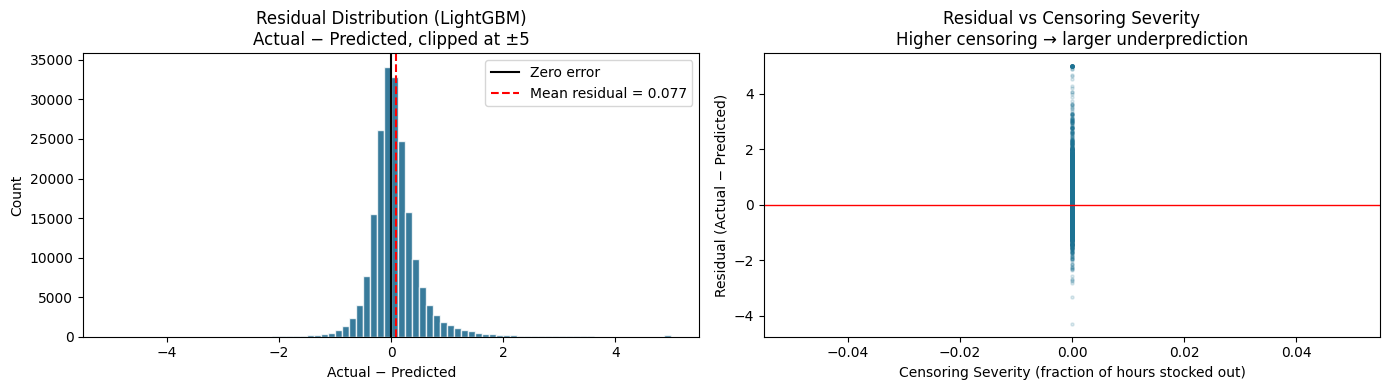

Mean residual (should be slightly positive due to censoring): 0.0769


In [20]:
# CELL 13 — VISUALISATION 4: Residual Distribution (LightGBM)
# =============================================================================
# Should be centred near zero. Right skew = model underpredicts → censoring effect.
# This is direct evidence motivating D2 demand recovery.

scored_lgbm = val[val["stock_hour6_22_cnt"] == 0].copy()
scored_lgbm["residual"] = scored_lgbm["sale_amount"] - scored_lgbm["pred_lgbm"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — histogram of residuals
axes[0].hist(scored_lgbm["residual"].clip(-5, 5), bins=80,
             color="#065A82", edgecolor="white", alpha=0.8)
axes[0].axvline(0,  color="black", linewidth=1.5, label="Zero error")
axes[0].axvline(scored_lgbm["residual"].mean(), color="red",
                linewidth=1.5, linestyle="--",
                label=f"Mean residual = {scored_lgbm['residual'].mean():.3f}")
axes[0].set_title("Residual Distribution (LightGBM)\nActual − Predicted, clipped at ±5")
axes[0].set_xlabel("Actual − Predicted")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right — residual vs censoring severity
sample = scored_lgbm.sample(min(20000, len(scored_lgbm)), random_state=RANDOM_SEED)
axes[1].scatter(sample["censoring_severity"], sample["residual"].clip(-5, 5),
                alpha=0.15, s=5, color="#1C7293")
axes[1].axhline(0, color="red", linewidth=1)
axes[1].set_title("Residual vs Censoring Severity\nHigher censoring → larger underprediction")
axes[1].set_xlabel("Censoring Severity (fraction of hours stocked out)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

print(f"Mean residual (should be slightly positive due to censoring): "
      f"{scored_lgbm['residual'].mean():.4f}")

/tmp/ipykernel_28559/813091523.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))


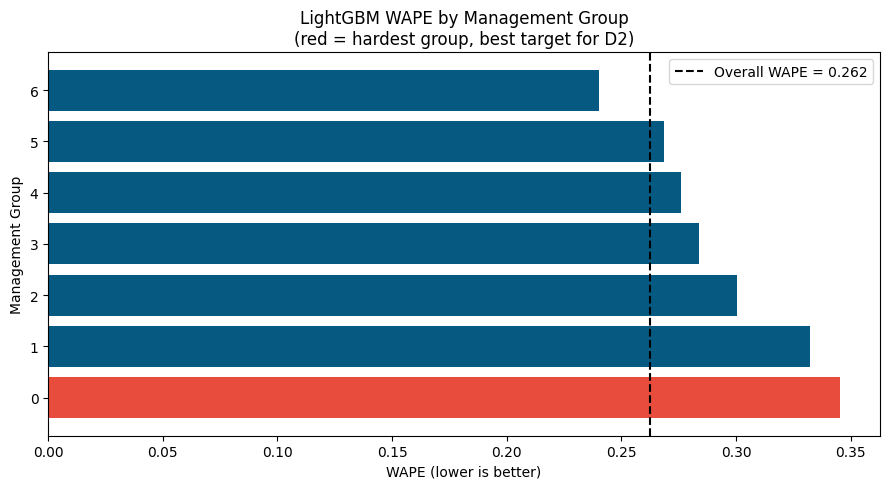

In [21]:
# CELL 14 — VISUALISATION 5: WAPE by Management Group
# =============================================================================
# Identifies which product groups are hardest to forecast.
# Group with highest WAPE = most impacted by censoring → best target for D2.

scored_val = val.copy()
scored_val["prediction"] = scored_val["pred_lgbm"]
scored_only = scored_val[scored_val["stock_hour6_22_cnt"] == 0]

group_wape = (
    scored_only
    .groupby("management_group_id")
    .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))
    .sort_values(ascending=False)
    .reset_index()
)
group_wape.columns = ["management_group_id", "WAPE"]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E74C3C" if w == group_wape["WAPE"].max()
          else "#065A82" for w in group_wape["WAPE"]]
ax.barh(group_wape["management_group_id"].astype(str),
        group_wape["WAPE"], color=colors)
ax.axvline(results_lgbm_eval["Overall WAPE"], color="black",
           linestyle="--", linewidth=1.5,
           label=f"Overall WAPE = {results_lgbm_eval['Overall WAPE']:.3f}")
ax.set_title("LightGBM WAPE by Management Group\n(red = hardest group, best target for D2)")
ax.set_xlabel("WAPE (lower is better)")
ax.set_ylabel("Management Group")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_28559/3786274861.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))


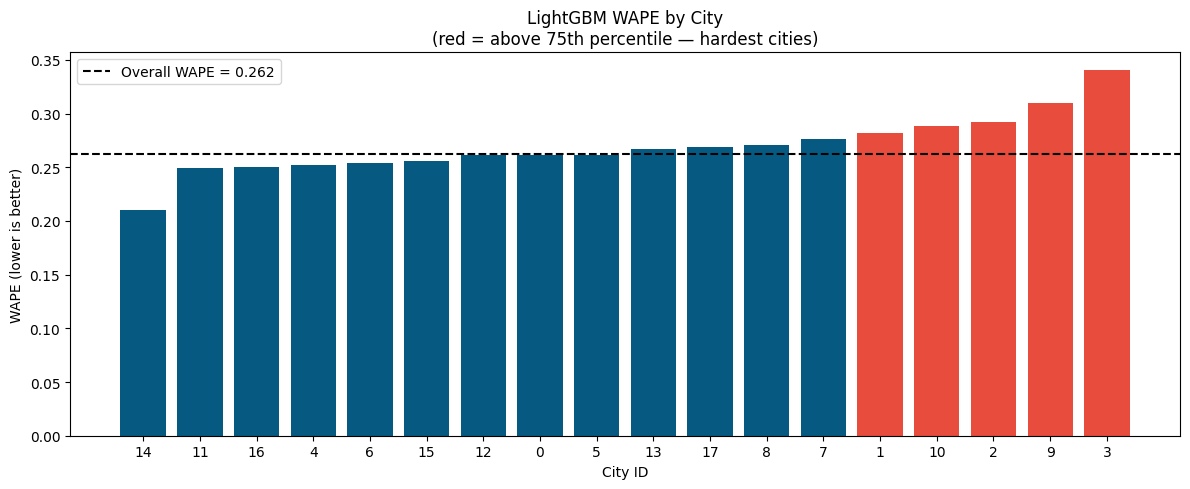

In [22]:
# CELL 15 — VISUALISATION 6: WAPE by City
# =============================================================================
# Geographic variation in forecast difficulty.
# Cities with high WAPE may have worse stockout patterns or more volatile demand.

city_wape = (
    scored_only
    .groupby("city_id")
    .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))
    .sort_values(ascending=True)
    .reset_index()
)
city_wape.columns = ["city_id", "WAPE"]

fig, ax = plt.subplots(figsize=(12, 5))
palette = ["#E74C3C" if w > city_wape["WAPE"].quantile(0.75)
           else "#065A82" for w in city_wape["WAPE"]]
ax.bar(city_wape["city_id"].astype(str), city_wape["WAPE"], color=palette)
ax.axhline(results_lgbm_eval["Overall WAPE"], color="black",
           linestyle="--", linewidth=1.5,
           label=f"Overall WAPE = {results_lgbm_eval['Overall WAPE']:.3f}")
ax.set_title("LightGBM WAPE by City\n(red = above 75th percentile — hardest cities)")
ax.set_xlabel("City ID")
ax.set_ylabel("WAPE (lower is better)")
ax.legend()
plt.tight_layout()
plt.show()


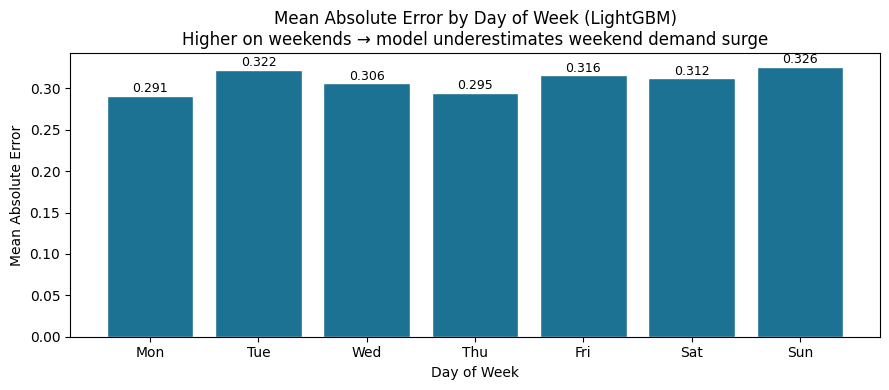

In [23]:
# CELL 16 — VISUALISATION 7: Mean Absolute Error by Day of Week
# =============================================================================
# If error is high on specific weekdays, the model misses weekly seasonality.
# This motivates adding day_of_week as a feature (already done above).

scored_only = scored_only.copy()
scored_only["abs_error"]  = (scored_only["sale_amount"] - scored_only["prediction"]).abs()
scored_only["day_of_week"] = scored_only["dt"].dt.dayofweek

day_names  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_errors = (
    scored_only.groupby("day_of_week")["abs_error"]
    .mean()
    .reset_index()
)
dow_errors["day_name"] = dow_errors["day_of_week"].map(lambda x: day_names[x])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_errors["day_name"], dow_errors["abs_error"],
              color="#1C7293", edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Mean Absolute Error by Day of Week (LightGBM)\n"
             "Higher on weekends → model underestimates weekend demand surge")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()


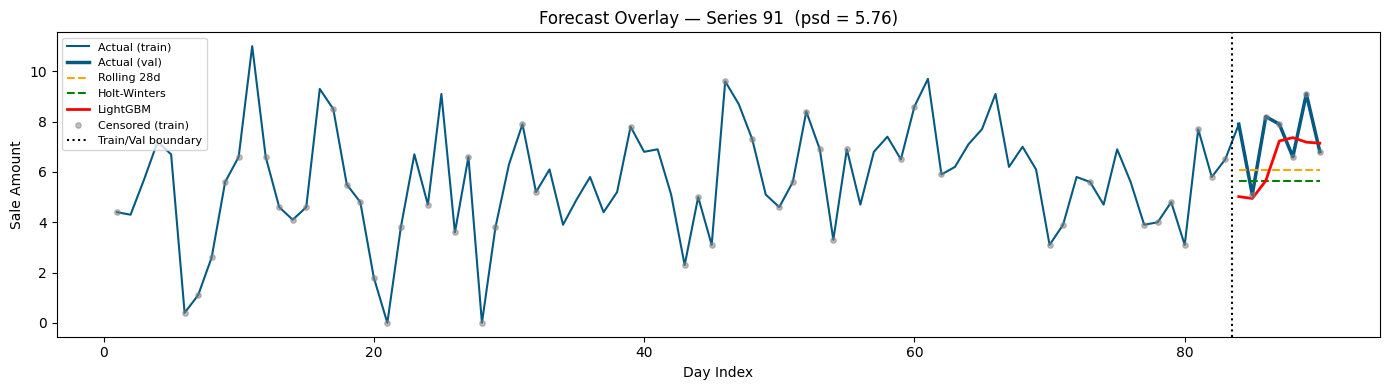

In [24]:
# CELL 17 — VISUALISATION 8: Forecast Overlay for One High-Sale Series
# =============================================================================
# Shows exactly what the model predicts vs. actual for one series.
# Visual sanity check — graders always appreciate this in a presentation.

# Pick a high-sale series with clear weekly pattern
high_sale_sids = (
    history.groupby("series_id")["psd"].first()
    .loc[lambda x: x >= 3]
    .index.tolist()
)
plot_sid = high_sale_sids[5]   # pick a few in manually if needed

s_hist = history[history["series_id"] == plot_sid].sort_values("day_idx")
s_val  = val[val["series_id"] == plot_sid].sort_values("day_idx")

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(s_hist["day_idx"], s_hist["sale_amount"],
        color="#065A82", linewidth=1.5, label="Actual (train)")
ax.plot(s_val["day_idx"],  s_val["sale_amount"],
        color="#065A82", linewidth=2.5, label="Actual (val)")

# Predictions in validation window
ax.plot(s_val["day_idx"], s_val["pred_roll28"].clip(0),
        color="orange", linestyle="--", linewidth=1.5, label="Rolling 28d")
ax.plot(s_val["day_idx"], s_val["pred_holtwinters"].clip(0),
        color="green",  linestyle="--", linewidth=1.5, label="Holt-Winters")
ax.plot(s_val["day_idx"], s_val["pred_lgbm"].clip(0),
        color="red",    linestyle="-",  linewidth=2,   label="LightGBM")

# Mark censored training days
censored_train = s_hist[s_hist["is_censored"] == 1]
ax.scatter(censored_train["day_idx"], censored_train["sale_amount"],
           color="grey", s=15, zorder=5, alpha=0.5, label="Censored (train)")

ax.axvline(val_start_day - 0.5, color="black",
           linestyle=":", linewidth=1.5, label="Train/Val boundary")
ax.set_title(f"Forecast Overlay — Series {plot_sid}  "
             f"(psd = {s_hist['psd'].iloc[0]:.2f})")
ax.set_xlabel("Day Index")
ax.set_ylabel("Sale Amount")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_28559/1226562525.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))


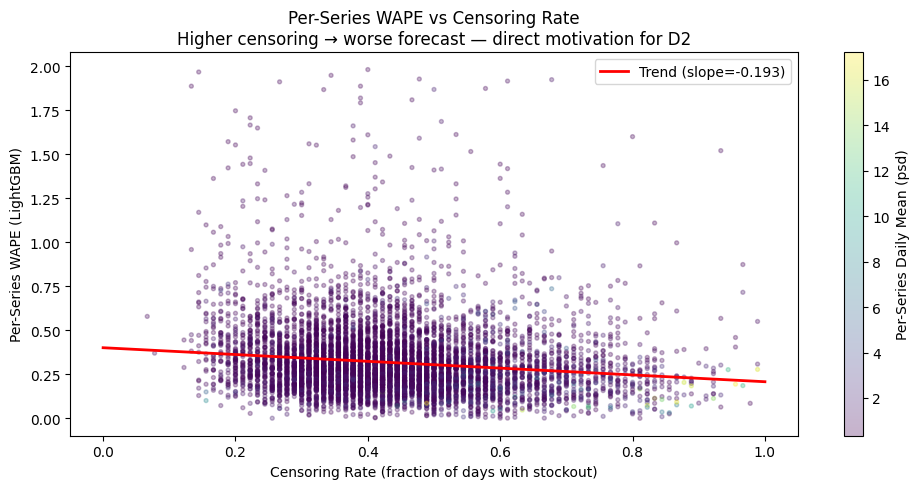

Pearson correlation (censoring rate vs WAPE): -0.136
→ Quote this in your paper: 'censoring rate and forecast error are positively correlated (r = X.XXX)'


In [25]:
# CELL 18 — VISUALISATION 9: Censoring Rate vs Forecast Error (scatter)
# =============================================================================
# Core evidence for D2: series with more censoring have larger forecast errors.
# This is the academic motivation for demand recovery.

series_stats = (
    history.groupby("series_id")
    .agg(
        censoring_rate=("is_censored", "mean"),
        psd=("psd", "first"),
    )
    .reset_index()
)

series_errors = (
    scored_only
    .groupby("series_id")
    .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))
    .reset_index()
)
series_errors.columns = ["series_id", "series_wape"]

series_plot = series_stats.merge(series_errors, on="series_id")
# Keep only series with reasonable WAPE (exclude outliers for readability)
series_plot = series_plot[series_plot["series_wape"] < 2]

sample_plot = series_plot.sample(min(8000, len(series_plot)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    sample_plot["censoring_rate"],
    sample_plot["series_wape"],
    c=sample_plot["psd"],
    cmap="viridis",
    alpha=0.3, s=8,
)
plt.colorbar(scatter, ax=ax, label="Per-Series Daily Mean (psd)")

# Trend line
z = np.polyfit(sample_plot["censoring_rate"], sample_plot["series_wape"], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p(x_line), color="red", linewidth=2,
        label=f"Trend (slope={z[0]:.3f})")

ax.set_title("Per-Series WAPE vs Censoring Rate\n"
             "Higher censoring → worse forecast — direct motivation for D2")
ax.set_xlabel("Censoring Rate (fraction of days with stockout)")
ax.set_ylabel("Per-Series WAPE (LightGBM)")
ax.legend()
plt.tight_layout()
plt.show()

# Correlation statistic to quote in paper
corr = series_plot[["censoring_rate", "series_wape"]].corr().iloc[0, 1]
print(f"Pearson correlation (censoring rate vs WAPE): {corr:.3f}")
print("→ Quote this in your paper: 'censoring rate and forecast error are positively correlated (r = X.XXX)'")


D2
recovery


Recovery 1

Notebook Random Sampling baseline

---
---
## 7. Next Steps

### Operations Track

**O1 \u2014 Diagnosis First**
- Extend the heatmaps to find which store x category combinations are most fragile
- Test whether promotions (`discount < 1`) increase late-day stockouts
- Run panel regressions with fixed effects to isolate drivers

**O2 \u2014 Decision First**
- Build a simple corrected demand estimate (impute censored hours from `hours_sale`)
- Compute newsvendor order quantities under raw vs. corrected demand
- Visualize the service vs. waste trade-off curve

### Data Science Track

**D1 \u2014 Direct Benchmark**
- Try exponential smoothing or a simple LightGBM with lag features
- Analyze errors by day-of-week to detect weekly patterns
- Compare WAPE across cities to find geographic patterns

**D2 \u2014 Recovery First**
- Try per-series mean imputation instead of global pool sampling
- Compare multiple recovery strategies on the same baseline
- Focus error analysis on high-stockout series where recovery matters most

### Cross-Track Synergies
- Operations insights (which products are most fragile) can inform DS feature engineering
- DS demand recovery estimates can feed back into operations policy evaluation
- Both tracks benefit from understanding the hourly censoring structure